In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

data_path = Path("../data/employee_attrition_feature_engineered.csv")

if not data_path.exists():
    data_path = Path("backend/data/employee_attrition_feature_engineered.csv")

df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1470, 33)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,CompanyExperienceRatio,PromotionFrequency,IncomePerYearExperience,SatisfactionScore,RoleTenureRatio
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,1,6,4,0,5,0.750000,0.000,749.125000,2.00,0.666667
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,3,10,7,1,7,1.000000,0.100,513.000000,3.00,0.700000
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,3,0,0,0,0,0.000000,0.000,298.571429,3.00,0.000000
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,8,7,3,0,1.000000,0.375,363.625000,3.25,0.875000
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,3,2,2,2,2,0.333333,1.000,578.000000,2.50,1.000000


Separate Target

In [3]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1470, 32)
Target: (1470,)


Check Numerical Features

In [4]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print(numeric_features)

Number of numerical features: 25
['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'CompanyExperienceRatio', 'PromotionFrequency', 'IncomePerYearExperience', 'SatisfactionScore', 'RoleTenureRatio']


Correlation with Target : Convert Attrition to 0/1

In [5]:
y_numeric = y.map({
    "Yes": 1,
    "No": 0
})

correlation = df[numeric_features].corrwith(y_numeric).sort_values(
    key=abs,
    ascending=False
)

print("Correlation with Attrition:")
print(correlation)

Correlation with Attrition:
TotalWorkingYears          -0.171063
JobLevel                   -0.169105
IncomePerYearExperience     0.169047
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
SatisfactionScore          -0.159092
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
RoleTenureRatio            -0.130324
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
DistanceFromHome            0.077924
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
RelationshipSatisfaction   -0.045872
NumCompaniesWorked          0.043494
YearsSinceLastPromotion    -0.033019
PromotionFrequency          0.031539
Education                  -0.031373
CompanyExperienceRatio     -0.016244
PercentSalaryHike          -0.013478
PerformanceRating           0.002889
dtype: float64


Visualize Important Correlations

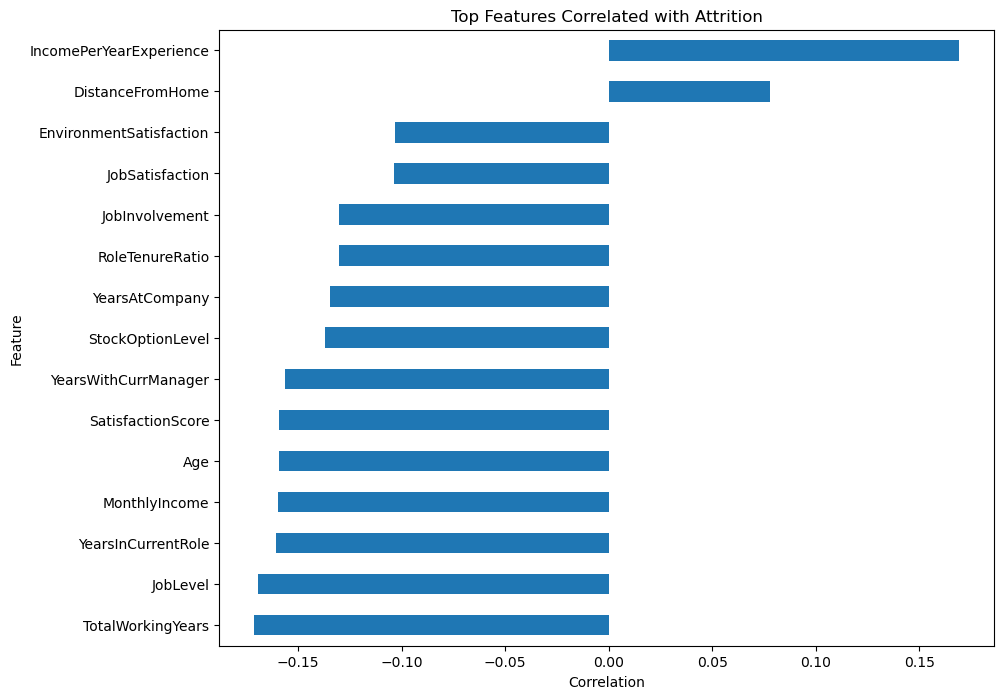

In [6]:
plt.figure(figsize=(10, 8))

correlation.head(15).sort_values().plot(kind="barh")

plt.title("Top Features Correlated with Attrition")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

Check Highly Correlated Features

In [7]:
corr_matrix = X[numeric_features].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_correlation = []

for column in upper.columns:
    for row in upper.index:
        if upper.loc[row, column] > 0.85:
            high_correlation.append(
                (row, column, upper.loc[row, column])
            )

print("Highly correlated feature pairs:")

if high_correlation:
    for feature1, feature2, value in high_correlation:
        print(f"{feature1} ↔ {feature2}: {value:.2f}")
else:
    print("No highly correlated feature pairs found.")

Highly correlated feature pairs:
JobLevel ↔ MonthlyIncome: 0.95


For this dataset, these columns don't provide useful predictive information

In [8]:
selected_features = [
    column for column in df.columns
    if column != "Attrition"
]

print("Selected features:")

for feature in selected_features:
    print("-", feature)

print("\nTotal selected features:", len(selected_features))

Selected features:
- Age
- BusinessTravel
- Department
- DistanceFromHome
- Education
- EducationField
- EnvironmentSatisfaction
- Gender
- JobInvolvement
- JobLevel
- JobRole
- JobSatisfaction
- MaritalStatus
- MonthlyIncome
- NumCompaniesWorked
- OverTime
- PercentSalaryHike
- PerformanceRating
- RelationshipSatisfaction
- StockOptionLevel
- TotalWorkingYears
- TrainingTimesLastYear
- WorkLifeBalance
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager
- CompanyExperienceRatio
- PromotionFrequency
- IncomePerYearExperience
- SatisfactionScore
- RoleTenureRatio

Total selected features: 32


In [9]:
selected_df = df[selected_features + ["Attrition"]].copy()

print("Selected dataset shape:", selected_df.shape)

selected_df.head()

Selected dataset shape: (1470, 33)


,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,CompanyExperienceRatio,PromotionFrequency,IncomePerYearExperience,SatisfactionScore,RoleTenureRatio,Attrition
0,41,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,2,...,6,4,0,5,0.750000,0.000,749.125000,2.00,0.666667,Yes
1,49,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,2,...,10,7,1,7,1.000000,0.100,513.000000,3.00,0.700000,No
2,37,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,1,...,0,0,0,0,0.000000,0.000,298.571429,3.00,0.000000,Yes
3,33,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,1,...,8,7,3,0,1.000000,0.375,363.625000,3.25,0.875000,No
4,27,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,1,...,2,2,2,2,0.333333,1.000,578.000000,2.50,1.000000,No


In [10]:
output_path = data_path.parent / "employee_attrition_selected.csv"

selected_df.to_csv(output_path, index=False)

print("Selected dataset saved successfully!")
print("Saved at:", output_path)

Selected dataset saved successfully!
Saved at: ..\data\employee_attrition_selected.csv
